--- Dataset Shape ---
Total Patients: 253680, Total Features: 22

--- Class Distribution (Target Variable) ---
Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

--- BMI Statistics ---
count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64


C:\Users\Harish Mohankumar\AppData\Local\Temp\ipykernel_12384\3167616165.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Diabetes_012', y='BMI', data=df, inner="quartile", palette="muted")


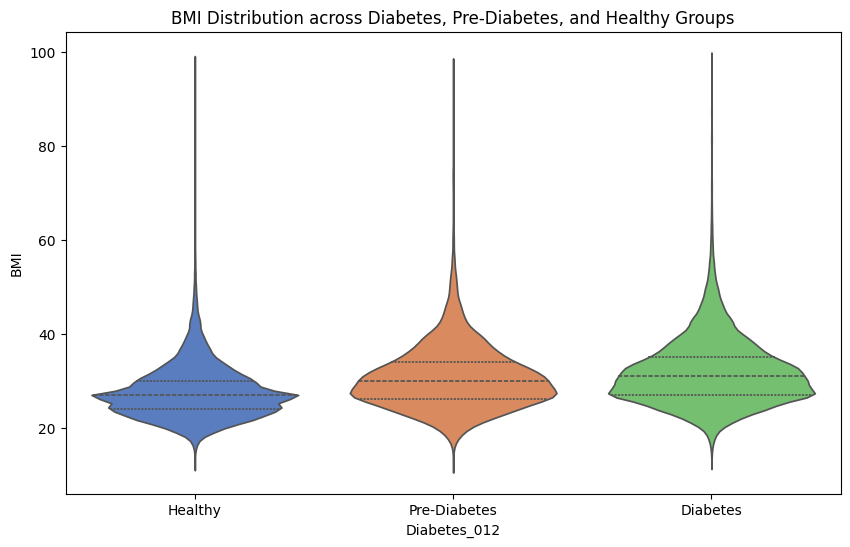

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset using your specific path
file_path = r"C:\Users\Harish Mohankumar\Downloads\diabetes_012_health_indicators_BRFSS2015.csv\diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)

# 2. Basic Health Check of the Data
print("--- Dataset Shape ---")
print(f"Total Patients: {df.shape[0]}, Total Features: {df.shape[1]}")

print("\n--- Class Distribution (Target Variable) ---")
# This tells us if we have enough 'Pre-diabetic' cases to study
print(df['Diabetes_012'].value_counts())

# 3. Medical Outlier Detection (Crucial Step)
# Let's check if there are impossible BMI values (e.g., BMI > 90 is extremely rare/error-prone)
print("\n--- BMI Statistics ---")
print(df['BMI'].describe())

# 4. Data Visualization: BMI vs. Diabetes Status
plt.figure(figsize=(10, 6))
sns.violinplot(x='Diabetes_012', y='BMI', data=df, inner="quartile", palette="muted")
plt.title('BMI Distribution across Diabetes, Pre-Diabetes, and Healthy Groups')
plt.xticks([0, 1, 2], ['Healthy', 'Pre-Diabetes', 'Diabetes'])
plt.show()

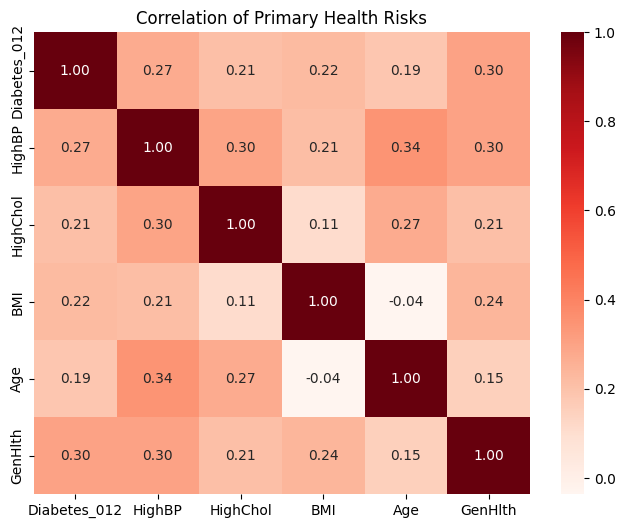

In [4]:
# 5. Correlation Analysis
# We want to see how much HighBP and HighChol impact the Diabetes score
cols = ['Diabetes_012', 'HighBP', 'HighChol', 'BMI', 'Age', 'GenHlth']
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Reds', fmt=".2f")
plt.title('Correlation of Primary Health Risks')
plt.show()

In [5]:
# Filter out extreme BMI outliers (keeping BMI between 10 and 60 for a cleaner study)
df_clean = df[(df['BMI'] >= 10) & (df['BMI'] <= 60)]

print(f"Removed {len(df) - len(df_clean)} extreme records.")

Removed 805 extreme records.


C:\Users\Harish Mohankumar\AppData\Local\Temp\ipykernel_12384\3841019966.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['BMI_Cat'] = pd.cut(df_clean['BMI'], bins=bins, labels=labels)
C:\Users\Harish Mohankumar\AppData\Local\Temp\ipykernel_12384\3841019966.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_profile = df_clean.groupby('BMI_Cat')['Diabetes_012'].value_counts(normalize=True).unstack() * 100


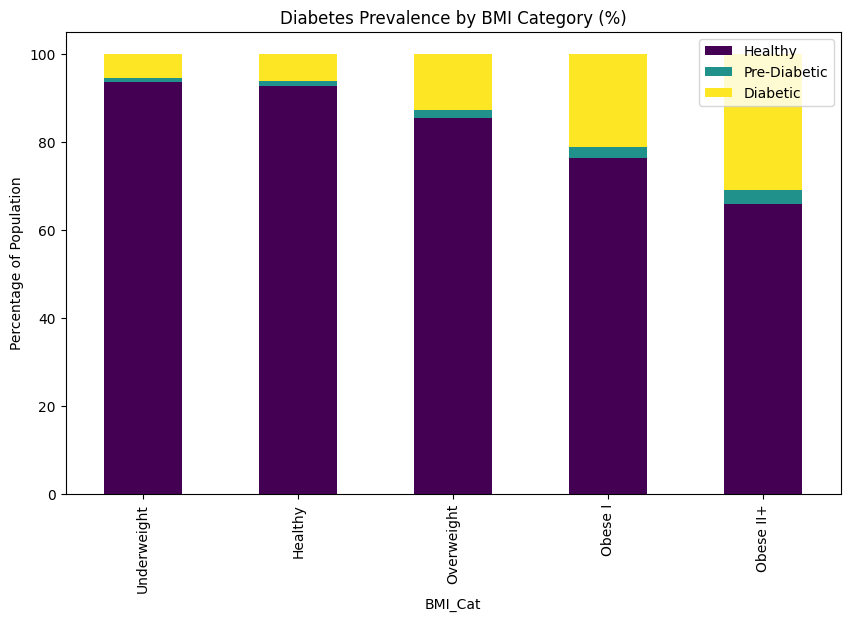

In [6]:
# Create BMI Categories
bins = [0, 18.5, 25, 30, 35, 100]
labels = ['Underweight', 'Healthy', 'Overweight', 'Obese I', 'Obese II+']
df_clean['BMI_Cat'] = pd.cut(df_clean['BMI'], bins=bins, labels=labels)

# Calculate the % of Diabetes in each category
risk_profile = df_clean.groupby('BMI_Cat')['Diabetes_012'].value_counts(normalize=True).unstack() * 100

# Plotting the Risk
risk_profile.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Diabetes Prevalence by BMI Category (%)')
plt.ylabel('Percentage of Population')
plt.legend(['Healthy', 'Pre-Diabetic', 'Diabetic'], loc='upper right')
plt.show()

In [7]:
plt.savefig('bmi_prevalence.png')

<Figure size 640x480 with 0 Axes>